# Laboratorio 11 — Minería de Texto: Preprocesamiento y Embeddings
**Curso:** Minería de Datos (EIN132A25) · USM

En este laboratorio recorrerás el pipeline completo de minería de texto visto en clase, desde el preprocesamiento hasta los embeddings contextuales modernos. Al final tendrás que aplicarlo a un dataset real de tu elección.

## Estructura

| Bloque | Tema | Técnica |
|---|---|---|
| I | Preprocesamiento | Tokenización, stopwords, lematización, normalización |
| II | TF-IDF | Vectorización estadística + clasificación |
| III | Word2Vec | Embeddings densos · semántica · analogías |
| IV | BERT | Embeddings contextuales con Transformers |
| V | **Ejercicios** | Aplicar todo a un dataset real |

## Resultados de aprendizaje
- Construir un pipeline reproducible de limpieza de texto en español.
- Comparar representaciones dispersas (TF-IDF) y densas (Word2Vec, BERT).
- Interpretar similitudes y analogías en el espacio vectorial.
- Aplicar embeddings a tareas reales: clasificación y búsqueda semántica.


## 0. Setup — Instalación de dependencias

Las primeras tres librerías ya vienen con `requirements.txt`. `gensim`, `transformers` y `sentence-transformers` son específicas de este lab — si no las tienes, descomenta el `!pip install`.

> **Nota CPU/GPU:** BERT funciona en CPU pero es lento. Si tienes GPU disponible (Colab por ejemplo), PyTorch la usará automáticamente.


In [1]:
# Descomenta si no las tienes instaladas:
!pip install --upgrade pip --quiet
!pip install nltk gensim "transformers>=4.30" torch sentence-transformers pandas numpy scikit-learn matplotlib seaborn --quiet

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, unicodedata
from collections import Counter

sns.set_style("whitegrid")
np.random.seed(42)

print("Setup OK")

Setup OK


In [3]:
# NLTK — descarga de recursos (solo la primera vez)
import nltk
for pkg in ["punkt", "punkt_tab", "stopwords"]:
    try:
        nltk.data.find(pkg)
    except LookupError:
        nltk.download(pkg, quiet=True)
print("NLTK listo")

NLTK listo


## Corpus de demostración

Trabajaremos con un mini-corpus de reseñas en español para que todos los ejemplos sean reproducibles sin descargar nada. Más adelante usarás tus propios datasets.


In [4]:
corpus = [
    "El gato gris duerme tranquilamente en la casa",
    "Los gatos son animales muy inteligentes y curiosos",
    "El perro juega alegremente en el parque con la pelota",
    "Mi perro y mi gato son los mejores amigos del mundo",
    "Fui al banco a sacar dinero de mi cuenta corriente",
    "Me senté en el banco del parque a leer un libro",
    "La película fue increíble, la actuación es excelente",
    "Una obra maestra, de lo mejor que he visto este año",
    "Muy aburrida la película, perdí el tiempo viendo este film",
    "Pésima actuación, guión sin sentido, no la recomiendo",
]
etiquetas = ["animal","animal","animal","animal",
             "lugar","lugar",
             "positivo","positivo","negativo","negativo"]

df = pd.DataFrame({"texto": corpus, "etiqueta": etiquetas})
df

,texto,etiqueta
0,El gato gris duerme tranquilamente en la casa,animal
1,Los gatos son animales muy inteligentes y curi...,animal
2,El perro juega alegremente en el parque con la...,animal
3,Mi perro y mi gato son los mejores amigos del ...,animal
4,Fui al banco a sacar dinero de mi cuenta corri...,lugar
5,Me senté en el banco del parque a leer un libro,lugar
6,"La película fue increíble, la actuación es exc...",positivo
7,"Una obra maestra, de lo mejor que he visto est...",positivo
8,"Muy aburrida la película, perdí el tiempo vien...",negativo
9,"Pésima actuación, guión sin sentido, no la rec...",negativo


---
# Bloque I — Preprocesamiento

> *Sin buena limpieza, los modelos no funcionan bien — garbage in, garbage out.*

Aplicaremos las 4 transformaciones clásicas: **tokenización → stopwords → lematización/stemming → normalización**.


### 1.1 Tokenización

Dividir el texto en unidades significativas. NLTK ofrece tokenizadores que respetan signos de puntuación.


In [5]:
from nltk.tokenize import word_tokenize, sent_tokenize

ejemplo = "El aprendizaje automático es fascinante. ¡Estudia minería de datos!"

print("Oraciones:")
for o in sent_tokenize(ejemplo, language="spanish"):
    print(" -", o)

print("\nTokens:")
print(word_tokenize(ejemplo, language="spanish"))

Oraciones:
 - El aprendizaje automático es fascinante.
 - ¡Estudia minería de datos!

Tokens:
['El', 'aprendizaje', 'automático', 'es', 'fascinante', '.', '¡Estudia', 'minería', 'de', 'datos', '!']


### 1.2 Eliminación de stopwords

Palabras como *el, la, de, es, y* tienen baja carga semántica. Cuidado: en análisis de sentimiento, *no* es técnicamente stopword pero invierte el significado — siempre validá tu dominio.


In [6]:
from nltk.corpus import stopwords

stop_es = set(stopwords.words("spanish"))
print(f"Total stopwords en español: {len(stop_es)}")
print("Algunas:", sorted(list(stop_es))[:20])

tokens = word_tokenize(ejemplo.lower(), language="spanish")
sin_stop = [t for t in tokens if t not in stop_es and t not in string.punctuation]
print("\nAntes:", tokens)
print("Después:", sin_stop)

Total stopwords en español: 313
Algunas: ['a', 'al', 'algo', 'algunas', 'algunos', 'ante', 'antes', 'como', 'con', 'contra', 'cual', 'cuando', 'de', 'del', 'desde', 'donde', 'durante', 'e', 'el', 'ella']

Antes: ['el', 'aprendizaje', 'automático', 'es', 'fascinante', '.', '¡estudia', 'minería', 'de', 'datos', '!']
Después: ['aprendizaje', 'automático', 'fascinante', '¡estudia', 'minería', 'datos']


### 1.3 Lematización vs Stemming

| Aspecto | Lematización | Stemming |
|---|---|---|
| Resultado | Forma base real (*correr*) | Truncamiento heurístico (*corr*) |
| Precisión | Alta | Baja |
| Velocidad | Lenta | Rápida |
| Requiere diccionario | Sí | No |

Para español usamos `SnowballStemmer` (stemming). Para lematización real conviene `spaCy` con el modelo `es_core_news_sm`. Aquí mostramos stemming porque no requiere descargas extra.


In [7]:
from nltk.stem import SnowballStemmer

stemmer = SnowballStemmer("spanish")
palabras = ["corriendo", "corrió", "corre", "gatos", "hermosas", "estudiando", "estudios"]

comparacion = pd.DataFrame({
    "original": palabras,
    "stem": [stemmer.stem(p) for p in palabras],
})
comparacion

,original,stem
0,corriendo,corr
1,corrió,corr
2,corre,corr
3,gatos,gat
4,hermosas,herm
5,estudiando,estudi
6,estudios,estudi


### 1.4 Normalización

Minúsculas, eliminación de acentos, puntuación y espacios redundantes — para que *"Café"*, *"CAFÉ"* y *"cafe"* sean el mismo token.


In [8]:
def quitar_acentos(texto: str) -> str:
    nfkd = unicodedata.normalize("NFKD", texto)
    return "".join(c for c in nfkd if not unicodedata.combining(c))

ejemplos = ["Café con leche", "¡HOLA, MUNDO!", "el  niño    pequeño"]
for t in ejemplos:
    t2 = quitar_acentos(t.lower())
    t2 = re.sub(rf"[{re.escape(string.punctuation)}¿¡]", "", t2)
    t2 = re.sub(r"\s+", " ", t2).strip()
    print(f"{t!r:35} → {t2!r}")

'Café con leche'                    → 'cafe con leche'
'¡HOLA, MUNDO!'                     → 'hola mundo'
'el  niño    pequeño'               → 'el nino pequeno'


### 1.5 Pipeline completo

Función única que aplica todas las transformaciones. La usaremos en los siguientes bloques.


In [9]:
def preprocesar(texto: str, lang: str = "spanish") -> list:
    # 1. Minúsculas
    texto = texto.lower()
    # 2. Quitar acentos
    texto = quitar_acentos(texto)
    # 3. Quitar puntuación y dígitos
    texto = re.sub(rf"[{re.escape(string.punctuation)}¿¡0-9]", " ", texto)
    # 4. Tokenizar
    tokens = word_tokenize(texto, language=lang)
    # 5. Quitar stopwords y tokens muy cortos
    tokens = [t for t in tokens if t not in stop_es and len(t) > 2]
    # 6. Stemming
    tokens = [stemmer.stem(t) for t in tokens]
    return tokens

df["tokens"] = df["texto"].apply(preprocesar)
df[["texto", "tokens"]]

,texto,tokens
0,El gato gris duerme tranquilamente en la casa,"[gat, gris, duerm, tranquil, cas]"
1,Los gatos son animales muy inteligentes y curi...,"[gat, animal, inteligent, curios]"
2,El perro juega alegremente en el parque con la...,"[perr, jueg, alegr, parqu, pelot]"
3,Mi perro y mi gato son los mejores amigos del ...,"[perr, gat, mejor, amig, mund]"
4,Fui al banco a sacar dinero de mi cuenta corri...,"[banc, sac, diner, cuent, corrient]"
5,Me senté en el banco del parque a leer un libro,"[sent, banc, parqu, leer, libr]"
6,"La película fue increíble, la actuación es exc...","[pelicul, increibl, actuacion, excelent]"
7,"Una obra maestra, de lo mejor que he visto est...","[obra, maestr, mejor, vist, ano]"
8,"Muy aburrida la película, perdí el tiempo vien...","[aburr, pelicul, perdi, tiemp, viend, film]"
9,"Pésima actuación, guión sin sentido, no la rec...","[pesim, actuacion, guion, recom]"


---
# Bloque II — TF-IDF

$$\text{TF-IDF}(w, d) = \underbrace{\frac{\text{frec}(w, d)}{|d|}}_{\text{TF}} \cdot \underbrace{\log\frac{N}{\text{df}(w)}}_{\text{IDF}}$$

- **TF** mide qué tan frecuente es la palabra en el documento.
- **IDF** penaliza palabras que aparecen en muchos documentos.

Las palabras raras y específicas obtienen el peso más alto → más poder discriminativo.


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Texto preprocesado (tokens reunidos como string)
df["texto_limpio"] = df["tokens"].apply(lambda toks: " ".join(toks))

vectorizer = TfidfVectorizer(max_features=30)
X_tfidf = vectorizer.fit_transform(df["texto_limpio"])

vocab = vectorizer.get_feature_names_out()
print(f"Shape de la matriz TF-IDF: {X_tfidf.shape}")
print(f"Vocabulario ({len(vocab)} términos): {list(vocab)}")

Shape de la matriz TF-IDF: (10, 30)
Vocabulario (30 términos): ['aburr', 'actuacion', 'alegr', 'amig', 'animal', 'ano', 'banc', 'cas', 'corrient', 'cuent', 'gat', 'inteligent', 'leer', 'libr', 'maestr', 'mejor', 'mund', 'obra', 'parqu', 'pelicul', 'pelot', 'perdi', 'perr', 'pesim', 'recom', 'sac', 'sent', 'tiemp', 'tranquil', 'viend']


In [11]:
# Visualizar la matriz TF-IDF como DataFrame
matriz = pd.DataFrame(X_tfidf.toarray(), columns=vocab,
                     index=[f"doc{i+1}" for i in range(len(df))])
matriz.round(3)

,aburr,actuacion,alegr,amig,animal,ano,banc,cas,corrient,cuent,...,pelot,perdi,perr,pesim,recom,sac,sent,tiemp,tranquil,viend
doc1,0.00,0.000,0.000,0.0,0.000,0.000,0.000,0.626,0.000,0.000,...,0.000,0.00,0.000,0.000,0.000,0.000,0.000,0.00,0.626,0.00
doc2,0.00,0.000,0.000,0.0,0.626,0.000,0.000,0.000,0.000,0.000,...,0.000,0.00,0.000,0.000,0.000,0.000,0.000,0.00,0.000,0.00
doc3,0.00,0.000,0.539,0.0,0.000,0.000,0.000,0.000,0.000,0.000,...,0.539,0.00,0.458,0.000,0.000,0.000,0.000,0.00,0.000,0.00
doc4,0.00,0.000,0.000,0.5,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.00,0.425,0.000,0.000,0.000,0.000,0.00,0.000,0.00
doc5,0.00,0.000,0.000,0.0,0.000,0.000,0.441,0.000,0.518,0.518,...,0.000,0.00,0.000,0.000,0.000,0.518,0.000,0.00,0.000,0.00
doc6,0.00,0.000,0.000,0.0,0.000,0.000,0.403,0.000,0.000,0.000,...,0.000,0.00,0.000,0.000,0.000,0.000,0.474,0.00,0.000,0.00
doc7,0.00,0.707,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.00,0.000,0.000,0.000,0.000,0.000,0.00,0.000,0.00
doc8,0.00,0.000,0.000,0.0,0.000,0.518,0.000,0.000,0.000,0.000,...,0.000,0.00,0.000,0.000,0.000,0.000,0.000,0.00,0.000,0.00
doc9,0.46,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.46,0.000,0.000,0.000,0.000,0.000,0.46,0.000,0.46
doc10,0.00,0.515,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.00,0.000,0.606,0.606,0.000,0.000,0.00,0.000,0.00


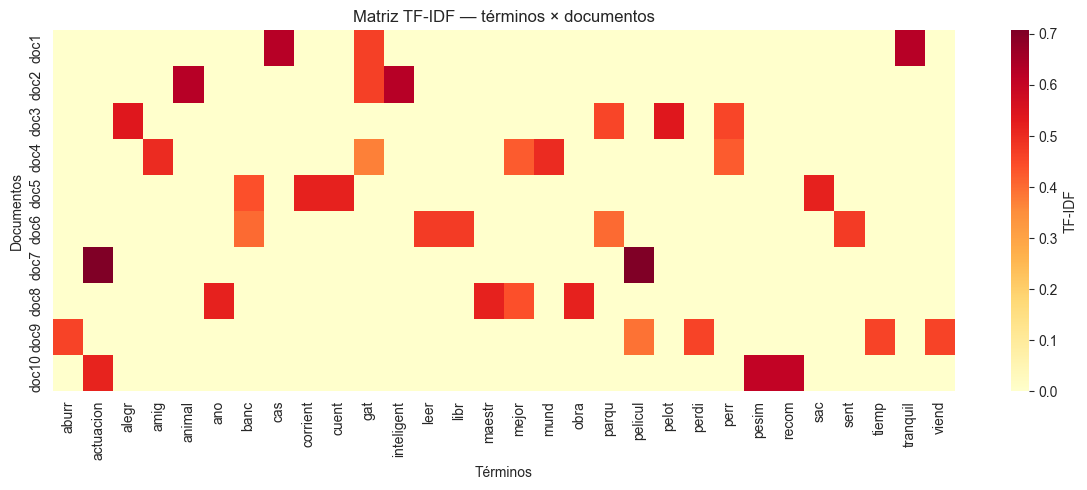

In [12]:
# Heatmap de la matriz TF-IDF
plt.figure(figsize=(12, 5))
sns.heatmap(matriz, cmap="YlOrRd", cbar_kws={"label": "TF-IDF"}, annot=False)
plt.title("Matriz TF-IDF — términos × documentos")
plt.xlabel("Términos")
plt.ylabel("Documentos")
plt.tight_layout()
plt.show()

### 2.1 Top palabras por documento

¿Qué palabra es más representativa de cada documento? Las de mayor TF-IDF.


In [13]:
for i, doc in enumerate(df["texto"]):
    fila = matriz.iloc[i]
    top = fila.nlargest(3)
    print(f"Doc {i+1}: {doc[:55]}...")
    print(f"   Top: {dict(top.round(3))}\n")

Doc 1: El gato gris duerme tranquilamente en la casa...
   Top: {'cas': np.float64(0.626), 'tranquil': np.float64(0.626), 'gat': np.float64(0.465)}

Doc 2: Los gatos son animales muy inteligentes y curiosos...
   Top: {'animal': np.float64(0.626), 'inteligent': np.float64(0.626), 'gat': np.float64(0.465)}

Doc 3: El perro juega alegremente en el parque con la pelota...
   Top: {'alegr': np.float64(0.539), 'pelot': np.float64(0.539), 'parqu': np.float64(0.458)}

Doc 4: Mi perro y mi gato son los mejores amigos del mundo...
   Top: {'amig': np.float64(0.5), 'mund': np.float64(0.5), 'mejor': np.float64(0.425)}

Doc 5: Fui al banco a sacar dinero de mi cuenta corriente...
   Top: {'corrient': np.float64(0.518), 'cuent': np.float64(0.518), 'sac': np.float64(0.518)}

Doc 6: Me senté en el banco del parque a leer un libro...
   Top: {'leer': np.float64(0.474), 'libr': np.float64(0.474), 'sent': np.float64(0.474)}

Doc 7: La película fue increíble, la actuación es excelente...
   Top: {'actuac

### 2.2 Clasificación con TF-IDF + Logistic Regression

Construimos un clasificador *positivo / negativo / animal / lugar* con TF-IDF como features. Con tan pocos datos el modelo es ilustrativo; en los ejercicios verás resultados reales.


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_predict

clf = LogisticRegression(max_iter=500, random_state=42)

# Con dataset tan pequeño usamos CV de 5 folds aproximado
y = df["etiqueta"].values
y_pred = cross_val_predict(clf, X_tfidf, y, cv=2)

print(classification_report(y, y_pred, zero_division=0))

              precision    recall  f1-score   support

      animal       0.40      1.00      0.57         4
       lugar       0.00      0.00      0.00         2
    negativo       0.00      0.00      0.00         2
    positivo       0.00      0.00      0.00         2

    accuracy                           0.40        10
   macro avg       0.10      0.25      0.14        10
weighted avg       0.16      0.40      0.23        10



---
# Bloque III — Word2Vec

Word2Vec aprende un vector denso por palabra (típicamente 100–300 dimensiones) usando el contexto. Palabras que aparecen en contextos similares terminan con vectores cercanos — *"dime con quién andas y te diré quién eres"*.

Dos arquitecturas:
- **CBOW** — predice palabra central desde el contexto. Rápido.
- **Skip-gram** — predice contexto desde palabra central. Mejor para palabras raras.


In [15]:
from gensim.models import Word2Vec

# Entrenamos con nuestro corpus preprocesado
oraciones_tokenizadas = df["tokens"].tolist()

w2v = Word2Vec(
    sentences=oraciones_tokenizadas,
    vector_size=50,    # bajamos a 50 dims porque el corpus es chico
    window=3,
    min_count=1,
    sg=1,              # 1=Skip-gram, 0=CBOW
    epochs=200,
    seed=42,
)

print(f"Vocabulario aprendido: {len(w2v.wv)} palabras")
primera_palabra = list(w2v.wv.key_to_index.keys())[0]
print(f"Ejemplo — vector de '{primera_palabra}': shape {w2v.wv[primera_palabra].shape}")
print(f"\nPrimeros 10 valores:")
print(w2v.wv[primera_palabra][:10].round(3))

Vocabulario aprendido: 40 palabras
Ejemplo — vector de 'gat': shape (50,)

Primeros 10 valores:
[-0.017  0.009  0.006 -0.002 -0.003  0.014 -0.019  0.01  -0.015 -0.015]


### 3.1 Palabras similares

Con un corpus tan pequeño los resultados son ruidosos, pero ilustran la mecánica.


In [16]:
for palabra in ["gat", "perr", "pelicul", "banc"]:
    if palabra in w2v.wv:
        sim = w2v.wv.most_similar(palabra, topn=3)
        print(f"Similares a '{palabra}':")
        for w, s in sim:
            print(f"   {w:15s} {s:+.3f}")
        print()
    else:
        print(f"'{palabra}' no está en el vocabulario\n")

Similares a 'gat':
   tranquil        +0.389
   inteligent      +0.288
   vist            +0.285

Similares a 'perr':
   gris            +0.487
   perdi           +0.371
   cuent           +0.353

Similares a 'pelicul':
   cas             +0.338
   banc            +0.317
   cuent           +0.286

Similares a 'banc':
   tiemp           +0.442
   film            +0.364
   animal          +0.358



### 3.2 Visualización 2D con PCA

Reducimos los vectores de 50D a 2D para inspeccionar visualmente la estructura aprendida.


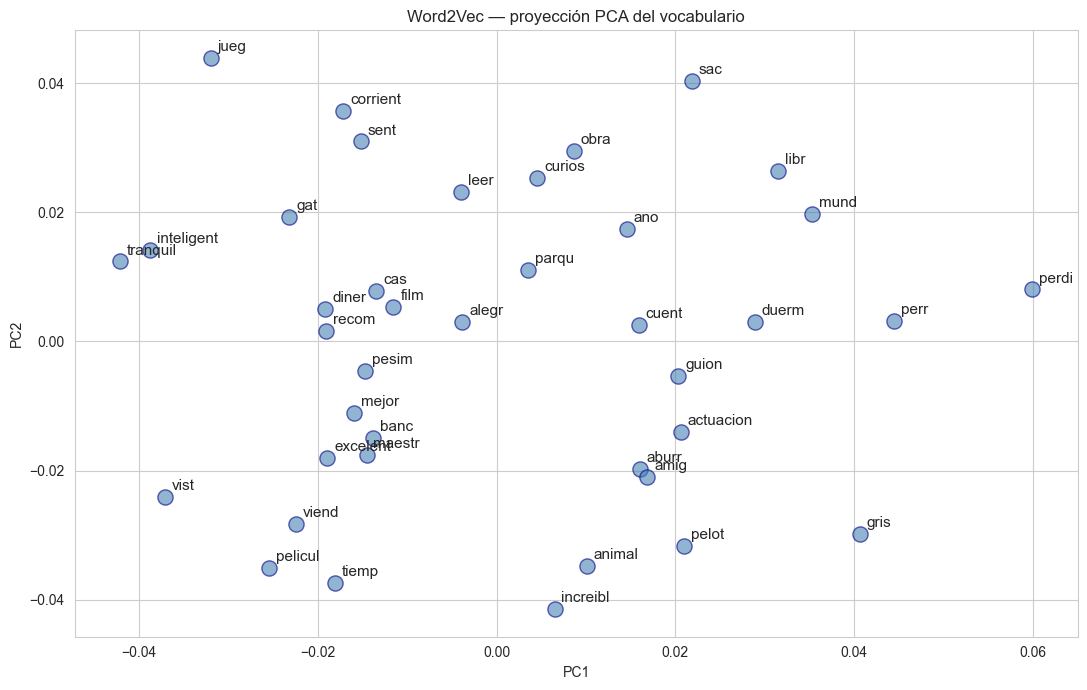

In [17]:
from sklearn.decomposition import PCA

palabras_viz = list(w2v.wv.key_to_index.keys())
vectores = np.array([w2v.wv[p] for p in palabras_viz])

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(vectores)

plt.figure(figsize=(11, 7))
plt.scatter(coords[:, 0], coords[:, 1], s=120, c="steelblue", alpha=0.6,
            edgecolor="navy")
for i, p in enumerate(palabras_viz):
    plt.annotate(p, (coords[i,0], coords[i,1]), fontsize=11,
                 xytext=(5, 5), textcoords="offset points")
plt.title("Word2Vec — proyección PCA del vocabulario")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.show()

> **Nota:** Para ver analogías clásicas como *rey − hombre + mujer ≈ reina* necesitarías un modelo entrenado en millones de oraciones. Puedes descargar uno pre-entrenado con `gensim.downloader.load('word2vec-google-news-300')` (~1.6 GB) o usar FastText en español.


---
# Bloque IV — BERT (embeddings contextuales)

Word2Vec asigna *un vector por palabra* sin importar el contexto. BERT genera **un vector distinto para la misma palabra en distintas oraciones** — esto resuelve el problema de la polisemia (*banco* dinero vs *banco* del parque).

Usaremos `sentence-transformers` con un modelo multilingüe pequeño (~120 MB) que corre bien en CPU.


In [18]:
from sentence_transformers import SentenceTransformer

# Modelo multilingüe pequeño — funciona bien en CPU
MODELO = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
modelo_bert = SentenceTransformer(MODELO)
print(f"Modelo cargado: {MODELO}")
print(f"Dimensión de embeddings: {modelo_bert.get_sentence_embedding_dimension()}")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modelo cargado: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Dimensión de embeddings: 384


### 4.1 Embeddings de oraciones

Cada oración se convierte en un único vector de 384 dimensiones.


In [19]:
embeddings = modelo_bert.encode(df["texto"].tolist(), show_progress_bar=False)
print(f"Shape: {embeddings.shape}  →  {embeddings.shape[0]} oraciones × {embeddings.shape[1]} dims")
print(f"\nPrimeros 8 valores del embedding de la oración 1:")
print(embeddings[0][:8].round(3))

Shape: (10, 384)  →  10 oraciones × 384 dims

Primeros 8 valores del embedding de la oración 1:
[ 0.408 -0.03  -0.094  0.349  0.012  0.037 -0.09   0.04 ]


### 4.2 Similitud semántica entre oraciones

Calculamos la similitud coseno entre cada par de oraciones. Las que hablan de lo mismo deberían tener similitud alta aunque usen palabras distintas.


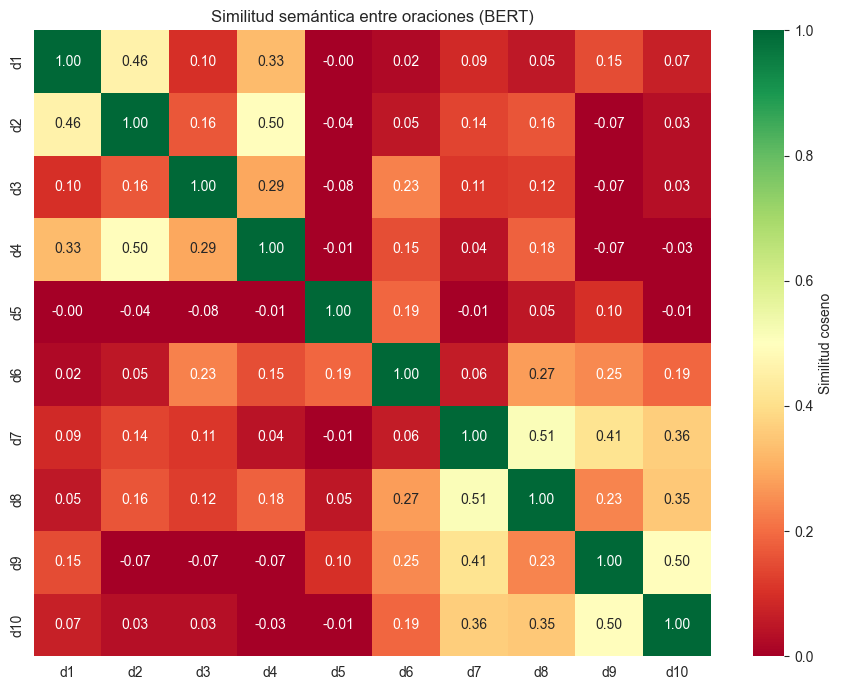

Referencia de las oraciones:
  d1: El gato gris duerme tranquilamente en la casa
  d2: Los gatos son animales muy inteligentes y curiosos
  d3: El perro juega alegremente en el parque con la pelota
  d4: Mi perro y mi gato son los mejores amigos del mundo
  d5: Fui al banco a sacar dinero de mi cuenta corriente
  d6: Me senté en el banco del parque a leer un libro
  d7: La película fue increíble, la actuación es excelente
  d8: Una obra maestra, de lo mejor que he visto este año
  d9: Muy aburrida la película, perdí el tiempo viendo este film
  d10: Pésima actuación, guión sin sentido, no la recomiendo


In [20]:
from sklearn.metrics.pairwise import cosine_similarity

sim = cosine_similarity(embeddings)
sim_df = pd.DataFrame(sim,
    index=[f"d{i+1}" for i in range(len(df))],
    columns=[f"d{i+1}" for i in range(len(df))])

plt.figure(figsize=(9, 7))
sns.heatmap(sim_df, annot=True, fmt=".2f", cmap="RdYlGn", center=0.5,
            vmin=0, vmax=1, cbar_kws={"label": "Similitud coseno"})
plt.title("Similitud semántica entre oraciones (BERT)")
plt.tight_layout()
plt.show()

print("Referencia de las oraciones:")
for i, t in enumerate(df["texto"], 1):
    print(f"  d{i}: {t}")

### 4.3 La magia del contexto: polisemia

La palabra *banco* aparece en dos oraciones con significados distintos. ¿BERT lo nota?


In [21]:
# Comparamos las dos oraciones con "banco"
i_dinero = 4  # "Fui al banco a sacar dinero..."
i_parque = 5  # "Me senté en el banco del parque..."

print(f"d{i_dinero+1} (finanzas): {df['texto'][i_dinero]}")
print(f"d{i_parque+1} (lugar):    {df['texto'][i_parque]}\n")

s_bert = cosine_similarity([embeddings[i_dinero]], [embeddings[i_parque]])[0,0]
print(f"Similitud BERT entre las dos oraciones con 'banco': {s_bert:.3f}")
print("→ Bajo, porque BERT ve los contextos completos y los entiende distintos.\n")

# Comparemos contra dos oraciones del MISMO contexto
print(f"Similitud BERT entre las dos oraciones de animales (d1 vs d2): "
      f"{cosine_similarity([embeddings[0]], [embeddings[1]])[0,0]:.3f}")
print(f"Similitud BERT entre dos reseñas positivas (d7 vs d8): "
      f"{cosine_similarity([embeddings[6]], [embeddings[7]])[0,0]:.3f}")

d5 (finanzas): Fui al banco a sacar dinero de mi cuenta corriente
d6 (lugar):    Me senté en el banco del parque a leer un libro

Similitud BERT entre las dos oraciones con 'banco': 0.191
→ Bajo, porque BERT ve los contextos completos y los entiende distintos.

Similitud BERT entre las dos oraciones de animales (d1 vs d2): 0.460
Similitud BERT entre dos reseñas positivas (d7 vs d8): 0.513


### 4.4 Búsqueda semántica

Dada una *query*, encuentra la oración más similar del corpus sin necesidad de keywords exactas.


In [22]:
def buscar(query: str, k: int = 3) -> pd.DataFrame:
    q_emb = modelo_bert.encode([query])
    sims = cosine_similarity(q_emb, embeddings)[0]
    idx = np.argsort(sims)[::-1][:k]
    return pd.DataFrame({
        "rank": range(1, k+1),
        "similitud": sims[idx].round(3),
        "texto": df["texto"].values[idx],
    })

# Probemos consultas
for q in ["mascotas adorables", "institución financiera", "cine de calidad"]:
    print(f"\nQuery: {q!r}")
    print(buscar(q, k=3).to_string(index=False))


Query: 'mascotas adorables'
 rank  similitud                                                 texto
    1      0.546   Mi perro y mi gato son los mejores amigos del mundo
    2      0.531    Los gatos son animales muy inteligentes y curiosos
    3      0.324 El perro juega alegremente en el parque con la pelota

Query: 'institución financiera'
 rank  similitud                                               texto
    1      0.392  Fui al banco a sacar dinero de mi cuenta corriente
    2      0.138 Una obra maestra, de lo mejor que he visto este año
    3      0.106  Los gatos son animales muy inteligentes y curiosos

Query: 'cine de calidad'
 rank  similitud                                                      texto
    1      0.557       La película fue increíble, la actuación es excelente
    2      0.421      Pésima actuación, guión sin sentido, no la recomiendo
    3      0.381 Muy aburrida la película, perdí el tiempo viendo este film


---
## Comparativa final

| Método | Dimensión | Contexto | Velocidad | Cuándo usar |
|---|---|---|---|---|
| **TF-IDF** | vocab (miles) | No | Muy rápida | Baseline · interpretable · datos limitados |
| **Word2Vec** | 100–300 | No (un vector por palabra) | Rápida | Captura sinónimos · sin GPU |
| **BERT** | 768 (o 384) | Sí (bidireccional) | Lenta (mejor GPU) | Máxima precisión · polisemia |


---
# Ejercicios con datasets reales

Aquí es donde aplicas todo lo anterior a datos del mundo real. **Elige UN dataset para cada ejercicio** — pueden ser distintos o el mismo. El texto está en todas partes, así que tienes libertad total.

### Ideas de dónde sacar datasets

**Bibliotecas de datasets listos:**
- [Kaggle Datasets](https://www.kaggle.com/datasets?tags=13208-Text+Data) — busca "spanish text" o "sentiment"
- [Hugging Face Datasets](https://huggingface.co/datasets) — `pip install datasets` y `load_dataset("imdb")`, `load_dataset("amazon_reviews_multi", "es")`, etc.
- [UCI Text Repositories](https://archive.ics.uci.edu/datasets?Type=Text)

**Texto que puedes scrapear o extraer:**
- Comentarios de YouTube (`youtube-comment-downloader`)
- Tweets / X (con API o herramientas como `snscrape` — verifica TOS actuales)
- Reseñas de productos (Amazon, MercadoLibre)
- Letras de canciones (Genius API)
- Artículos de Wikipedia (`wikipedia-api`)
- Subreddits (`praw` o el dump público de Pushshift)
- Noticias (RSS de medios, Google News)
- Tus propios chats / WhatsApp exportado / correos

**Texto en español (recomendado para validar lo del curso):**
- [pysentimiento spanish_tweets](https://huggingface.co/datasets/pysentimiento/spanish_tweets)
- [muchocine reviews](https://huggingface.co/datasets/muchocine)
- RSS de El Mundo / La Nación / Emol / La Tercera

> **Tamaño sugerido:** 500 – 5.000 documentos. Suficiente para ver resultados sin que demore eternidades.


## Ejercicio 1 — Clasificación de texto con TF-IDF

**Objetivo:** Construir y evaluar un clasificador de texto sobre un dataset real con al menos 2 clases.

### Pasos sugeridos
1. **Carga el dataset** en un DataFrame con columnas `texto` y `etiqueta` (binaria o multiclase).
2. **Reporta estadísticas:** cantidad de documentos, distribución de clases, longitud promedio en tokens.
3. **Aplica tu pipeline `preprocesar()`** del Bloque I.
4. **Vectoriza con TF-IDF** — experimenta con `min_df`, `max_df`, `ngram_range=(1,2)`.
5. **Entrena al menos 2 clasificadores** (LogisticRegression, MultinomialNB, LinearSVC, RandomForest).
6. **Evalúa** con accuracy, F1 macro y matriz de confusión sobre un split train/test (o k-fold).
7. **Interpreta:** ¿qué palabras tienen los coeficientes más altos para cada clase?

### Preguntas a responder
- ¿Qué algoritmo funcionó mejor y por qué?
- ¿Qué palabras son las más discriminativas para tu mejor clase?
- ¿Dónde se confunde más el modelo? (mira la matriz de confusión)
- ¿Cómo cambia el rendimiento si quitas los stopwords o no?

### Tu código aquí


## Ejercicio 2 — Búsqueda semántica con embeddings

**Objetivo:** Construir un mini buscador semántico sobre un corpus de texto usando embeddings de BERT.

### Pasos sugeridos
1. **Reúne un corpus de 100–1.000 documentos** (artículos, párrafos, comentarios, capítulos de un libro, etc.). No necesita etiquetas.
2. **Genera embeddings** de todo el corpus con `sentence-transformers`.
3. **Implementa la función `buscar(query, k)`** que devuelva los `k` documentos más similares por coseno.
4. **Prueba con 5 queries distintas** — incluye al menos una donde las palabras de la query *no* aparezcan literalmente en los resultados (para mostrar que es semántica, no léxica).
5. **Compara contra TF-IDF.** Usa el mismo corpus, vectoriza con `TfidfVectorizer`, y haz la misma búsqueda. ¿En qué casos BERT gana? ¿En cuáles TF-IDF es suficiente?
6. **Bonus:** Visualiza el corpus en 2D con algún método de reducción de dimensiones (t-SNE, UMAP, PCA) coloreando por una variable que tengas (categoría, fecha, autor).

### Preguntas a responder
- Muestra 2 queries donde BERT encuentra resultados que TF-IDF se pierde.
- ¿Cuánto tarda en encodear todo el corpus? ¿Y en hacer una búsqueda?
- Si tu corpus tuviera 1 millón de documentos, ¿qué problema tendrías y cómo lo resolverías? *(pista: FAISS, ANN, indexado)*
- ¿La visualización 2D refleja la estructura semántica esperada?

### Tu código aquí


### Recursos
- [scikit-learn — Text feature extraction](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction)
- [gensim — Word2Vec tutorial](https://radimrehurek.com/gensim/models/word2vec.html)
- [sentence-transformers docs](https://www.sbert.net/)
- [Hugging Face course](https://huggingface.co/course)
